# Homework1 Regression Analysis
**学号**：SA25006010
**姓名**：周子涵


## 一、任务说明与方法概览
 数据集：该数据为混凝土抗压强度数据，共 1030 实例。8 输入变量，1 输出变量。
 方法：数据集中共有 8 个输入特征。一般而言，我们可以选择相关性更高的特征，以获得更好的结果。为此可以使用相关性分析或主成分分析等机器学习方法挑选数据集中的主要特征，以下列举了一些可能使用到的分析方法：
 相关性分析：通过计算各个特征与混凝土强度之间的相关性，选择与强度具有较高相关性的特征作为主要特征。
 主成分分析：将原始特征进行降维，提取能够解释大部分数据方差的主成分作为主要特征。

## 二、实验目标
本实验旨在基于混凝土配比、龄期等输入特征，建立抗压强度预测模型。

推荐的方法：线性回归或者构建神经网络。
下面以神经网络方法为例阐述具体的操作过程：
 数据准备：将数据集的前 80%作为训练集，后 20%作为测试集。
 数据预处理：对训练集和测试集的特征进行预处理（如：对缺失值进行处理），确保输入数据有相同的维度。
 神经网络构建：在 Python 中使用 Pytorch 等神经网络框架构建一个适合回归问题的神经网络模型，包括输入层、隐藏层和输出层。可以选择使用多个隐藏层和不同的激活函数测试效果。
 模型训练：使用训练集对神经网络模型进行训练，通过反向传播算法更新权重和偏置。
 模型测试和评估：使用测试集对训练好的神经网络模型进行测试，计算预测值与实际值之间的均方误差作为评价指标。同时，可以通过测试集的 target 与神经网络模型输出的 output，进行绘图，将神经网络模型的性能进行可视化。

## 三、代码实现

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from torch.utils.data import TensorDataset, DataLoader
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [2]:
# 1. 数据加载
df = pd.read_csv("Concrete_Data_Yeh.csv")
print("="*30 + "数据集基本信息" + "="*30)
print(f"数据集形状：{df.shape}")
print("缺失值统计：", df.isnull().sum().sum())


==============================数据集基本信息==============================
数据集形状：(1030, 9)
缺失值统计： 0



==============================特征与强度相关性==============================
csMPa               1.000000
cement              0.497832
superplasticizer    0.366079
age                 0.328873
slag                0.134829
flyash             -0.105755
coarseaggregate    -0.164935
fineaggregate      -0.167241
water              -0.289633
Name: csMPa, dtype: float64

==============================筛选结果==============================
筛选高相关特征：['cement', 'superplasticizer', 'age', 'water']
特征数量：4


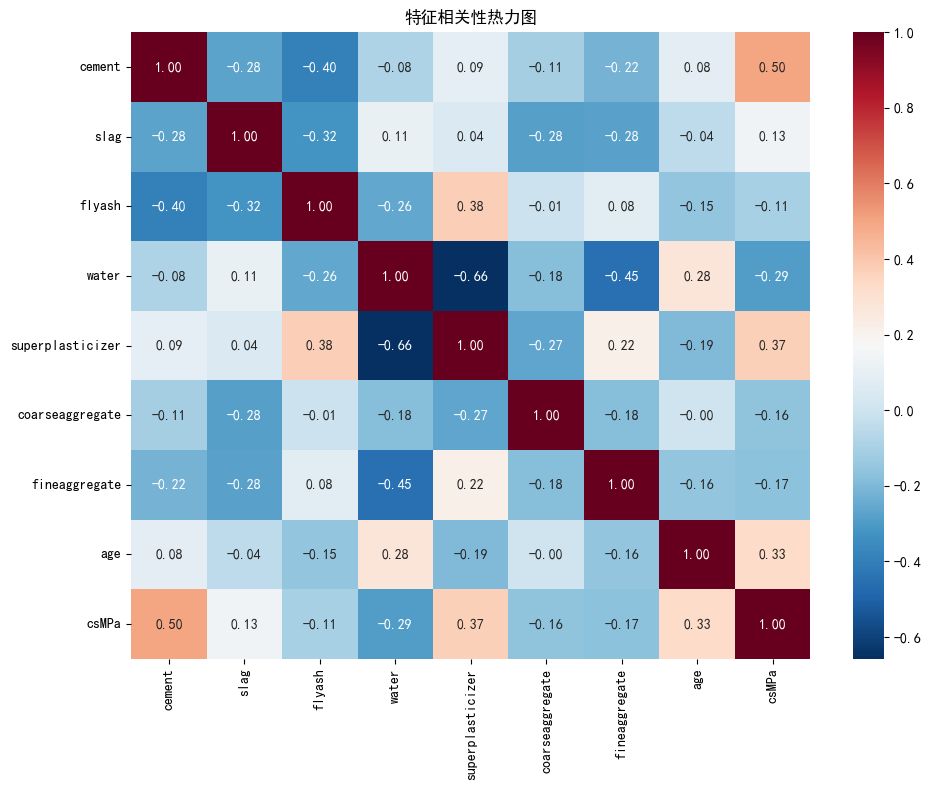

In [3]:
# 2. 高相关特征筛选
corr_matrix = df.corr()
corr_with_target = corr_matrix['csMPa'].sort_values(ascending=False)
print("\n" + "="*30 + "特征与强度相关性" + "="*30)
print(corr_with_target)

# 筛选阈值：绝对值高相关特征
CORR_THRESHOLD = 0.25
selected_features = corr_with_target[
    (abs(corr_with_target) > CORR_THRESHOLD) & 
    (corr_with_target.index != 'csMPa')
].index.tolist()

print("\n" + "="*30 + "筛选结果" + "="*30)
print(f"筛选高相关特征：{selected_features}")
print(f"特征数量：{len(selected_features)}")

# 绘制热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('特征相关性热力图')
plt.tight_layout()
plt.savefig('相关性热力图.png', dpi=300)
plt.show()

PCA 后主成分数: 6


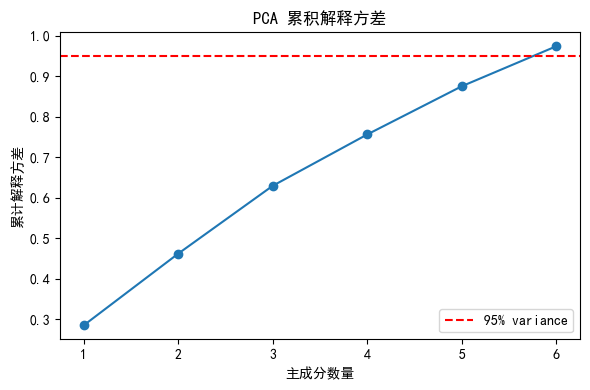

In [4]:
# 3. 主成分分析(PCA)
X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values.reshape(-1, 1)
feature_names = df.columns[:-1]
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA 后主成分数: {X_pca.shape[1]}')

cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('主成分数量')
plt.ylabel('累计解释方差')
plt.title('PCA 累积解释方差')
plt.legend()
plt.tight_layout()
plt.savefig('PCA累积解释方差.png', dpi=300)
plt.show()

### 主成分分析（PCA）解释
主成分分析（Principal Component Analysis，PCA）是一种无监督线性降维算，是数据预处理中最常用的特征提取方法。其核心作用是：在最大限度保留数据核心信息的前提下，将高维、存在相关性的原始特征，转换为低维、彼此无关的新特征（主成分），消除特征冗余、简化模型输入。

核心原理：
1. 数据标准化：统一特征量纲，避免数值差异影响降维效果；
2. 协方差分析：计算特征间相关性，识别数据中的冗余信息；
3. 主成分提取：通过特征值分解，筛选携带信息最多的维度；
4. 数据投影：将原始数据投影到主成分维度，完成降维。

本实验中的应用：
本次实验针对8维混凝土配比特征，设置保留95%累计解释方差，最终将数据降维至6个主成分：


In [5]:
# 4. 数据划分与标准化
X_train, X_test, Y_train, Y_test = train_test_split(
    X_pca, Y, test_size=0.2, random_state=42
)
scaler_Y = StandardScaler()
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)

# 5. 线性回归
lr = LinearRegression()
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(Y_test, Y_pred_lr)
r2_lr = r2_score(Y_test, Y_pred_lr)

print("\n" + "="*30 + "线性回归结果" + "="*30)
print(f"测试集MSE: {mse_lr:.2f}")
print(f"测试集R²: {r2_lr:.2f}")


==============================线性回归结果==============================
测试集MSE: 111.03
测试集R²: 0.57


In [6]:
# 6. 优化神经网络
# 张量转换
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_scaled, dtype=torch.float32)

# 数据加载器
train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, Y_test_tensor), batch_size=16, shuffle=False)

class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),  
            nn.ReLU(),         
            nn.Linear(64, 32),          
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

# 初始化
model = SimpleNN(input_dim=X_pca.shape[1])
criterion = nn.MSELoss()
# L2正则化(weight_decay) + 调整学习率
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 训练
epochs = 300
train_loss = []
test_loss = []

print("\n" + "="*30 + "神经网络训练" + "="*30)
for epoch in range(epochs):
    model.train()
    total_train = 0
    for x, y in train_loader:
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train += loss.item() * x.size(0)
    
    
    # 记录损失
    train_l = total_train / len(X_train)
    train_loss.append(train_l)
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | 训练损失:{train_l:.4f} ")


==============================神经网络训练==============================
Epoch  20 | 训练损失:0.1295 
Epoch  40 | 训练损失:0.0995 
Epoch  60 | 训练损失:0.0771 
Epoch  80 | 训练损失:0.0637 
Epoch 100 | 训练损失:0.0593 
Epoch 120 | 训练损失:0.0545 
Epoch 140 | 训练损失:0.0491 
Epoch 160 | 训练损失:0.0434 
Epoch 180 | 训练损失:0.0423 
Epoch 200 | 训练损失:0.0414 
Epoch 220 | 训练损失:0.0396 
Epoch 240 | 训练损失:0.0373 
Epoch 260 | 训练损失:0.0374 
Epoch 280 | 训练损失:0.0354 
Epoch 300 | 训练损失:0.0336 



==============================优化后神经网络结果==============================
测试集MSE: 39.19
测试集R²: 0.85


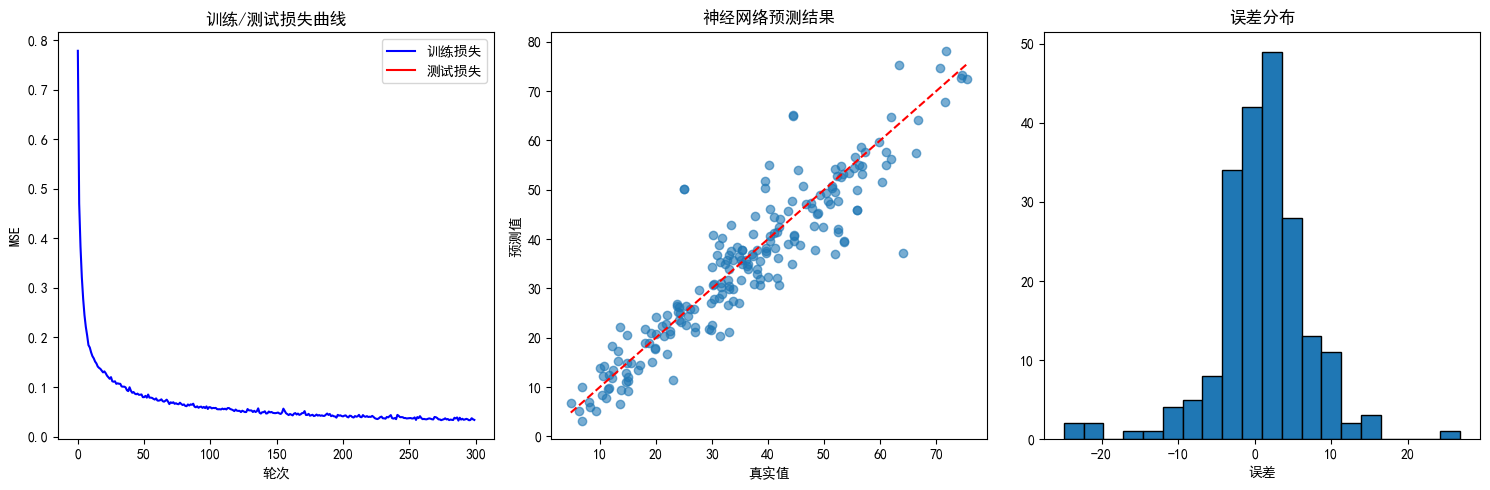


==============================最终总结==============================
 线性回归 MSE: 111.03
 神经网络 MSE: 39.19


In [7]:
# 7. 模型评估
model.eval()
with torch.no_grad():
    y_pred_nn = scaler_Y.inverse_transform(model(X_test_tensor).numpy())
mse_nn = mean_squared_error(Y_test, y_pred_nn)
r2_nn = r2_score(Y_test, y_pred_nn)

print("\n" + "="*30 + "优化后神经网络结果" + "="*30)
print(f"测试集MSE: {mse_nn:.2f}")
print(f"测试集R²: {r2_nn:.2f}")

# ======================================================
# 8. 可视化
plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
plt.plot(train_loss, label='训练损失', c='blue')
plt.plot(test_loss, label='测试损失', c='red')
plt.xlabel('轮次')
plt.ylabel('MSE')
plt.title('训练/测试损失曲线')
plt.legend()

# 预测对比
plt.subplot(1,3,2)
plt.scatter(Y_test, y_pred_nn, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel('真实值')
plt.ylabel('预测值')
plt.title('神经网络预测结果')

# 误差分布
plt.subplot(1,3,3)
plt.hist(Y_test - y_pred_nn, bins=20, edgecolor='black')
plt.xlabel('误差')
plt.title('误差分布')

plt.tight_layout()
plt.savefig('优化后结果.png', dpi=300)
plt.show()

# ======================================================
# 总结
print("\n" + "="*30 + "最终总结" + "="*30)
print(f" 线性回归 MSE: {mse_lr:.2f}")
print(f" 神经网络 MSE: {mse_nn:.2f}")